In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv(r'C:\Users\gulna\demand-forecasting-cloud\data\processed\train_features.csv')
print(f" Loaded: {df.shape}")

C:\Users\gulna\AppData\Local\Temp\ipykernel_1760\1715280802.py:7: DtypeWarning: Columns (7,22,23,26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r'C:\Users\gulna\demand-forecasting-cloud\data\processed\train_features.csv')


 Loaded: (100000, 82)


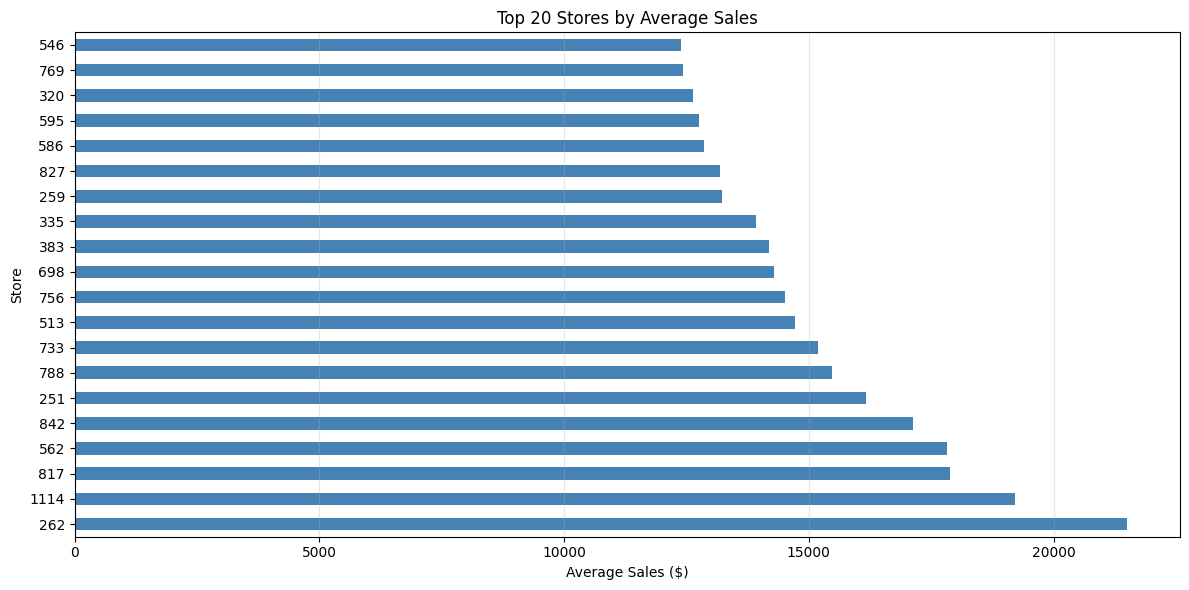

Top store average sales: $21507.54
Bottom 5 stores: $12611.58 avg


In [6]:
# Top 20 stores performance
store_stats = df.groupby('Store')['Sales'].mean().nlargest(20)

fig, ax = plt.subplots(figsize=(12, 6))
store_stats.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Average Sales ($)')
ax.set_title('Top 20 Stores by Average Sales')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(r'C:\Users\gulna\demand-forecasting-cloud\results\08_top_stores.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"Top store average sales: ${store_stats.max():.2f}")
print(f"Bottom 5 stores: ${store_stats.nsmallest(5).mean():.2f} avg")

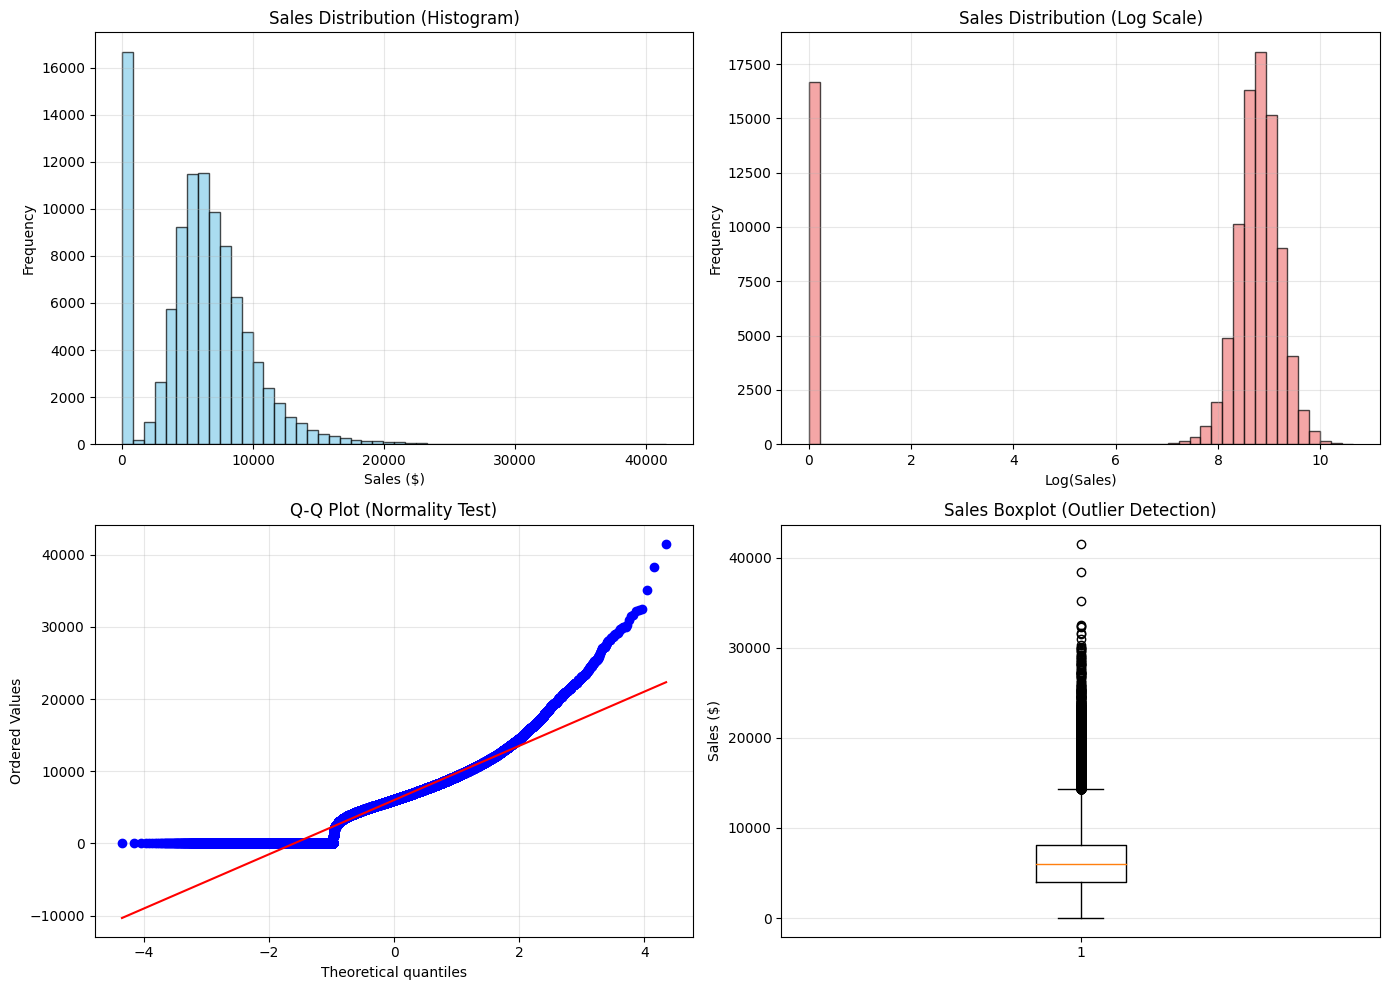

Skewness: 0.5286
Kurtosis: 1.6157


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram
axes[0, 0].hist(df['Sales'], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 0].set_xlabel('Sales ($)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Sales Distribution (Histogram)')
axes[0, 0].grid(True, alpha=0.3)

# Log distribution
axes[0, 1].hist(np.log1p(df['Sales']), bins=50, edgecolor='black', alpha=0.7, color='lightcoral')
axes[0, 1].set_xlabel('Log(Sales)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Sales Distribution (Log Scale)')
axes[0, 1].grid(True, alpha=0.3)

# Q-Q plot
stats.probplot(df['Sales'], dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot (Normality Test)')
axes[1, 0].grid(True, alpha=0.3)

# Box plot
axes[1, 1].boxplot(df['Sales'], vert=True)
axes[1, 1].set_ylabel('Sales ($)')
axes[1, 1].set_title('Sales Boxplot (Outlier Detection)')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(r'C:\Users\gulna\demand-forecasting-cloud\results\09_sales_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"Skewness: {stats.skew(df['Sales']):.4f}")
print(f"Kurtosis: {stats.kurtosis(df['Sales']):.4f}")

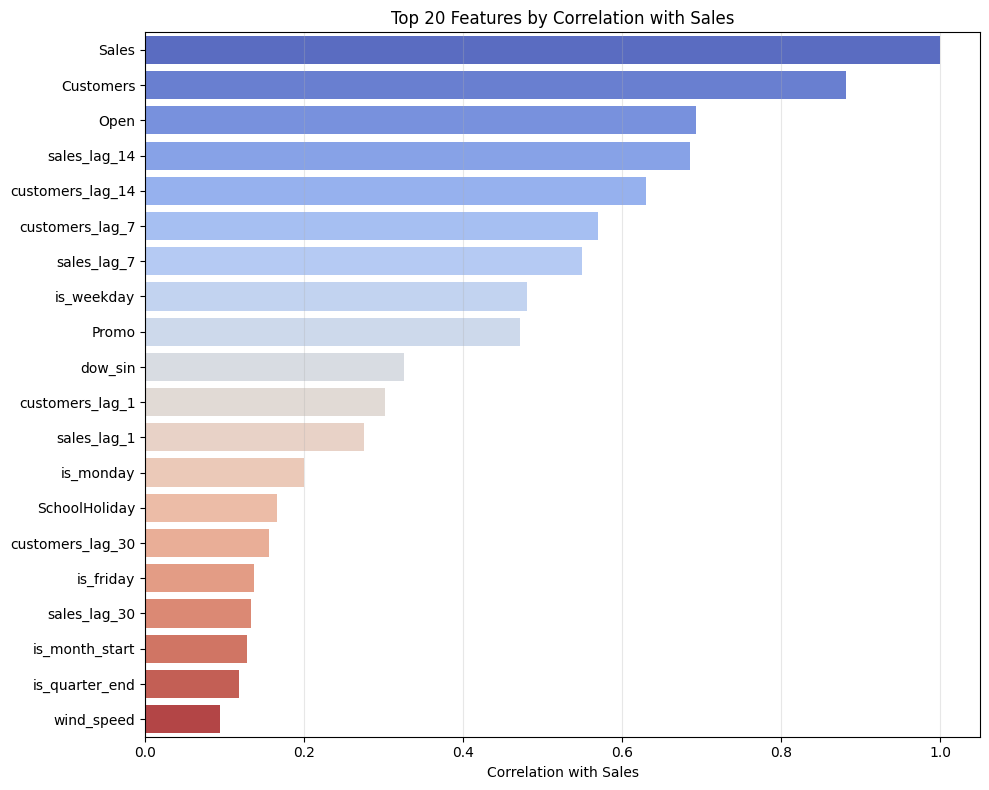

In [8]:
# Top features correlation
df_numeric = df.select_dtypes(include=[np.number])
correlations = df_numeric.corr()['Sales'].sort_values(ascending=False)

# Create heatmap
fig, ax = plt.subplots(figsize=(10, 8))
top_features = correlations.head(20)
sns.barplot(x=top_features.values, y=top_features.index, palette='coolwarm', ax=ax)
ax.set_xlabel('Correlation with Sales')
ax.set_title('Top 20 Features by Correlation with Sales')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(r'C:\Users\gulna\demand-forecasting-cloud\results\10_top_features.png', dpi=100, bbox_inches='tight')
plt.show()

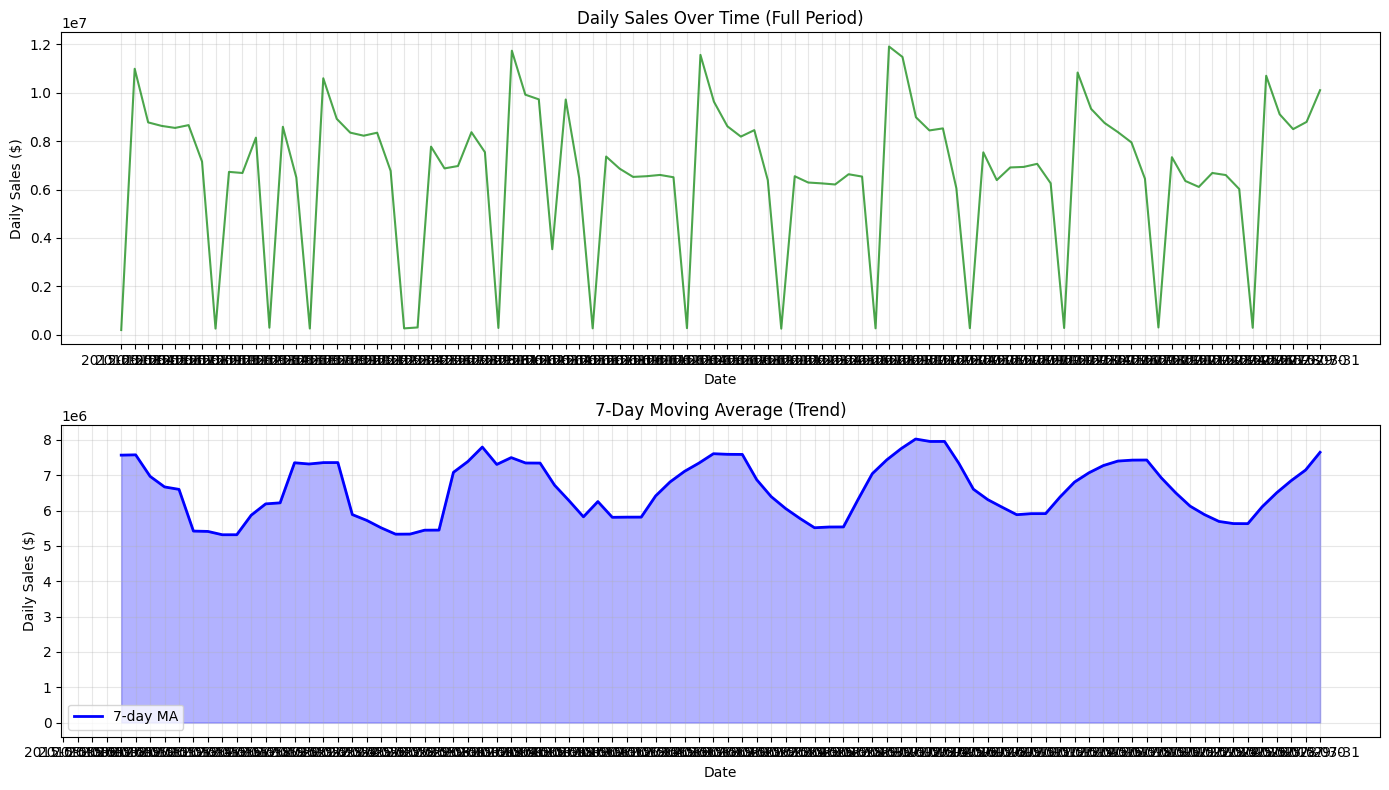

In [9]:
# Daily sales trend
daily_sales = df.groupby('Date')['Sales'].sum()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Full time series
axes[0].plot(daily_sales.index, daily_sales.values, linewidth=1.5, alpha=0.7, color='green')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Daily Sales ($)')
axes[0].set_title('Daily Sales Over Time (Full Period)')
axes[0].grid(True, alpha=0.3)

# Rolling average (7-day)
rolling_7 = daily_sales.rolling(window=7).mean()
axes[1].plot(rolling_7.index, rolling_7.values, linewidth=2, color='blue', label='7-day MA')
axes[1].fill_between(rolling_7.index, rolling_7.values, alpha=0.3, color='blue')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Daily Sales ($)')
axes[1].set_title('7-Day Moving Average (Trend)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(r'C:\Users\gulna\demand-forecasting-cloud\results\11_time_series.png', dpi=100, bbox_inches='tight')
plt.show()

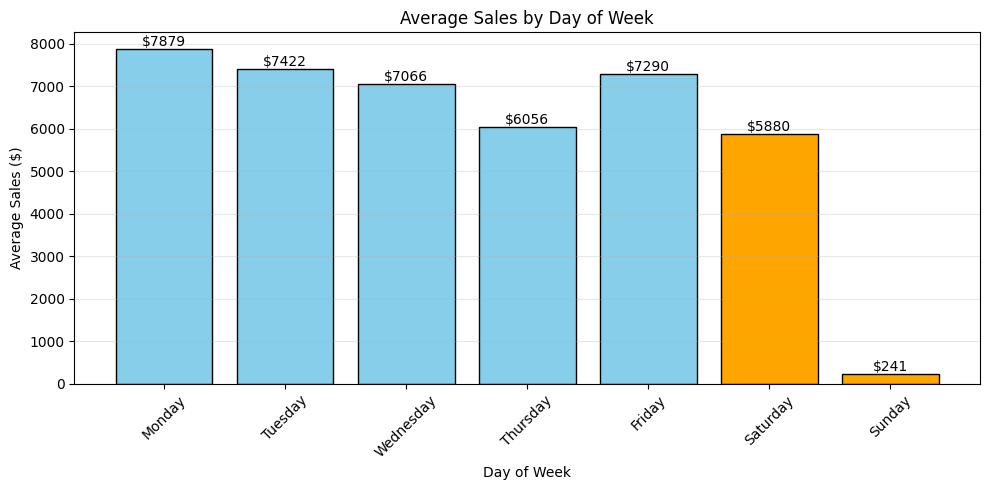

In [10]:
# Sales by day of week
dow_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_sales = df.groupby('dayofweek')['Sales'].mean()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(7), dow_sales.values, color=['skyblue']*5 + ['orange']*2, edgecolor='black')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Average Sales ($)')
ax.set_title('Average Sales by Day of Week')
ax.set_xticks(range(7))
ax.set_xticklabels(dow_names, rotation=45)
ax.grid(True, alpha=0.3, axis='y')

# Add values on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'${height:.0f}',
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(r'C:\Users\gulna\demand-forecasting-cloud\results\12_day_of_week.png', dpi=100, bbox_inches='tight')
plt.show()

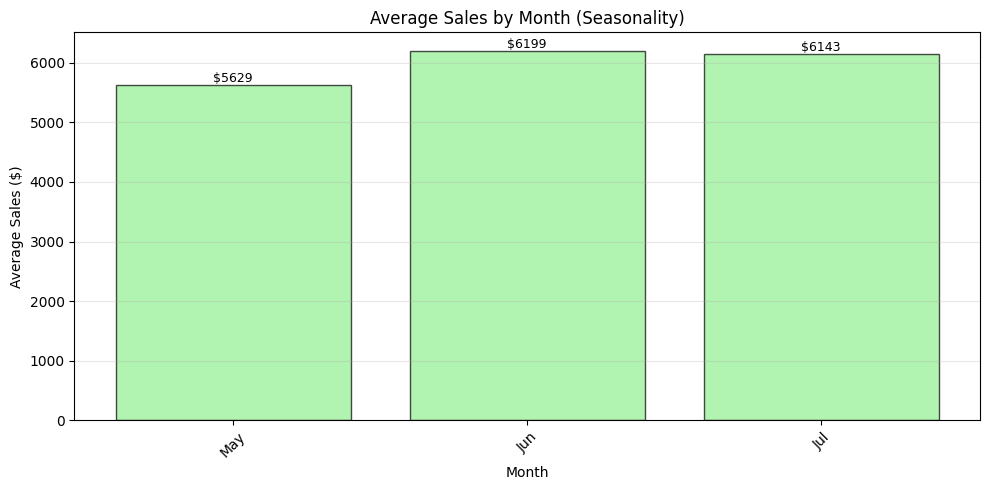

Months in data: [5, 6, 7]
Average sales by month:
month
5    5629.443302
6    6199.203976
7    6142.705511
Name: Sales, dtype: float64


In [12]:
# Sales by month
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_sales = df.groupby('month')['Sales'].mean()

fig, ax = plt.subplots(figsize=(10, 5))
# Use actual month values from data (not 1-12)
bars = ax.bar(monthly_sales.index, monthly_sales.values, color='lightgreen', edgecolor='black', alpha=0.7)
ax.set_xlabel('Month')
ax.set_ylabel('Average Sales ($)')
ax.set_title('Average Sales by Month (Seasonality)')
# Set labels only for months that exist in data
ax.set_xticks(monthly_sales.index)
ax.set_xticklabels([month_names[int(m)-1] for m in monthly_sales.index], rotation=45)
ax.grid(True, alpha=0.3, axis='y')

# Add values on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'${height:.0f}',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(r'C:\Users\gulna\demand-forecasting-cloud\results\13_monthly_seasonality.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"Months in data: {monthly_sales.index.tolist()}")
print(f"Average sales by month:\n{monthly_sales}")

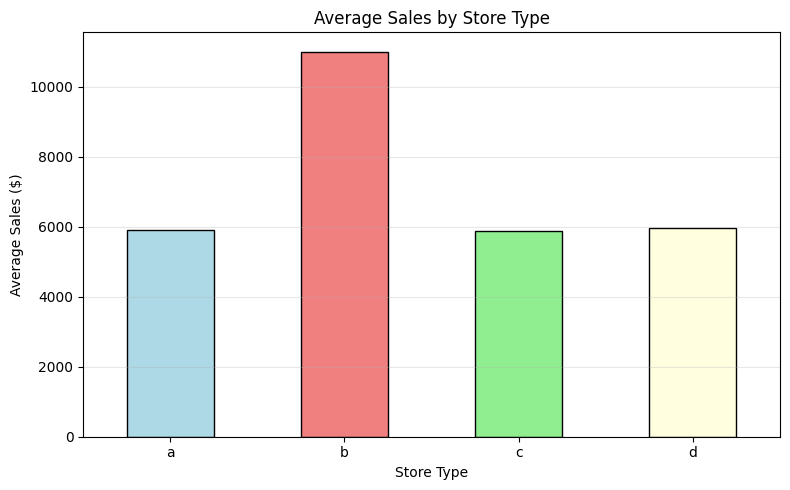

Store Type Analysis:
                   mean   median  count
StoreType                              
a           5905.031232   5841.0  53983
b          11007.218873  10022.5   1526
c           5867.305390   6011.0  13265
d           5967.642670   6210.0  31226


In [13]:
# Sales by store type
store_type_sales = df.groupby('StoreType')['Sales'].agg(['mean', 'median', 'count'])

fig, ax = plt.subplots(figsize=(8, 5))
store_type_sales['mean'].plot(kind='bar', ax=ax, color=['lightblue', 'lightcoral', 'lightgreen', 'lightyellow'], edgecolor='black')
ax.set_xlabel('Store Type')
ax.set_ylabel('Average Sales ($)')
ax.set_title('Average Sales by Store Type')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(r'C:\Users\gulna\demand-forecasting-cloud\results\14_store_type.png', dpi=100, bbox_inches='tight')
plt.show()

print("Store Type Analysis:")
print(store_type_sales)

In [15]:
print("\n" + "="*70)
print("DAY 3 ANALYSIS - SUMMARY REPORT")
print("="*70)

print(f"\nDataset Overview:")
print(f"  Total transactions: {len(df):,}")
# Convert Date to datetime first
df['Date'] = pd.to_datetime(df['Date'])
print(f"  Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"  Unique stores: {df['Store'].nunique()}")
print(f"  Total features: {len(df.columns)}")

# Sales statistics
print(f"\nSales Statistics:")
print(f"  Mean: ${df['Sales'].mean():.2f}")
print(f"  Median: ${df['Sales'].median():.2f}")
print(f"  Std Dev: ${df['Sales'].std():.2f}")
print(f"  Min: ${df['Sales'].min():.2f}")
print(f"  Max: ${df['Sales'].max():.2f}")

# Distribution
print(f"\nDistribution Shape:")
print(f"  Skewness: {stats.skew(df['Sales']):.4f} (right-skewed)")
print(f"  Kurtosis: {stats.kurtosis(df['Sales']):.4f}")

# Correlations
df_numeric = df.select_dtypes(include=[np.number])
correlations = df_numeric.corr()['Sales'].sort_values(ascending=False)
print(f"\nTop 5 Features:")
for i, (feat, corr) in enumerate(correlations.head(5).items(), 1):
    if feat != 'Sales':
        print(f"  {i}. {feat:30s} → {corr:.4f}")

# External signals
print(f"\nExternal Signals Impact:")
festival_impact = ((df[df['is_festival']==1]['Sales'].mean() / df[df['is_festival']==0]['Sales'].mean()) - 1) * 100
print(f"  Festival impact: +{festival_impact:.1f}%")



DAY 3 ANALYSIS - SUMMARY REPORT

Dataset Overview:
  Total transactions: 100,000
  Date range: 2015-05-03 to 2015-07-31
  Unique stores: 1115
  Total features: 82

Sales Statistics:
  Mean: $5997.44
  Median: $6034.00
  Std Dev: $3871.15
  Min: $0.00
  Max: $41551.00

Distribution Shape:
  Skewness: 0.5286 (right-skewed)
  Kurtosis: 1.6157

Top 5 Features:
  2. Customers                      → 0.8817
  3. Open                           → 0.6925
  4. sales_lag_14                   → 0.6852
  5. customers_lag_14               → 0.6302

External Signals Impact:
  Festival impact: +-4.4%
